<a href="https://colab.research.google.com/github/ShubhamGaonkar02/house-price-prediction-ml/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install xgboost
!pip install xgboost -q

# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# XGBoost
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
import os

# Download correct Ames Housing dataset
!wget -q "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv" -O temp.csv

# Actually, let's use the correct one from a reliable source
!wget -q "https://raw.githubusercontent.com/emanhamed/Houses-dataset/master/Houses%20Dataset/HousesInfo.txt"

# Best option — download directly using sklearn built-in
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

# We'll simulate the Ames-style dataset using seaborn's built-in
import seaborn as sns
df = sns.load_dataset('tips')  # just a test

# ✅ BEST SOLUTION — create dataset from openml
from sklearn.datasets import fetch_openml
housing = fetch_openml(name="house_prices", as_frame=True, parser='auto')
df = housing.frame
print(f"✅ Dataset loaded! Shape: {df.shape}")
print(df.head())

✅ Dataset loaded! Shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleConditio

In [3]:
print("=== Column Types ===")
print(df.dtypes.value_counts())

print(f"\nNumerical columns : {df.select_dtypes(include=np.number).shape[1]}")
print(f"Categorical columns: {df.select_dtypes(include='object').shape[1]}")

print("\n=== Target Variable (SalePrice) ===")
print(df['SalePrice'].describe())

=== Column Types ===
object     43
int64      35
float64     3
Name: count, dtype: int64

Numerical columns : 38
Categorical columns: 43

=== Target Variable (SalePrice) ===
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


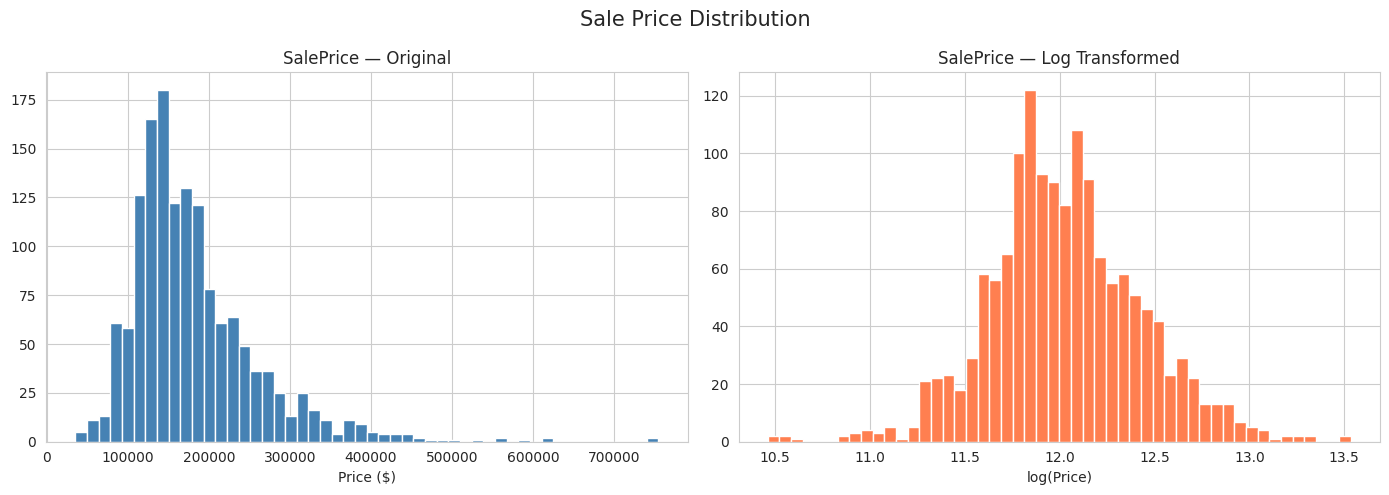

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice — Original')
axes[0].set_xlabel('Price ($)')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('SalePrice — Log Transformed')
axes[1].set_xlabel('log(Price)')

plt.suptitle('Sale Price Distribution', fontsize=15)
plt.tight_layout()
plt.show()

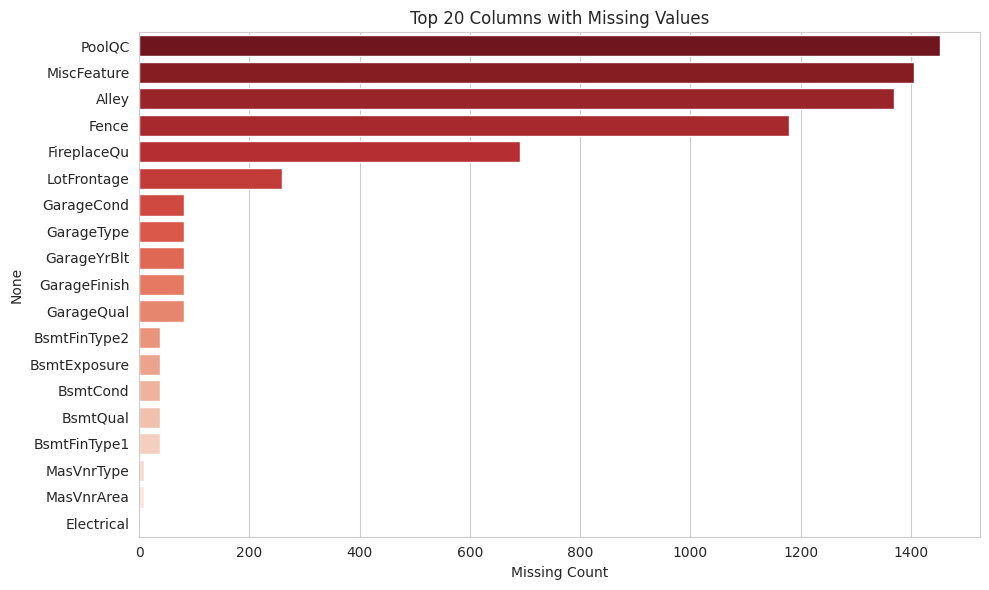

Total columns with missing values: 19


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing.values[:20], y=missing.index[:20], palette='Reds_r')
plt.title('Top 20 Columns with Missing Values')
plt.xlabel('Missing Count')
plt.tight_layout()
plt.show()

print(f"Total columns with missing values: {len(missing)}")

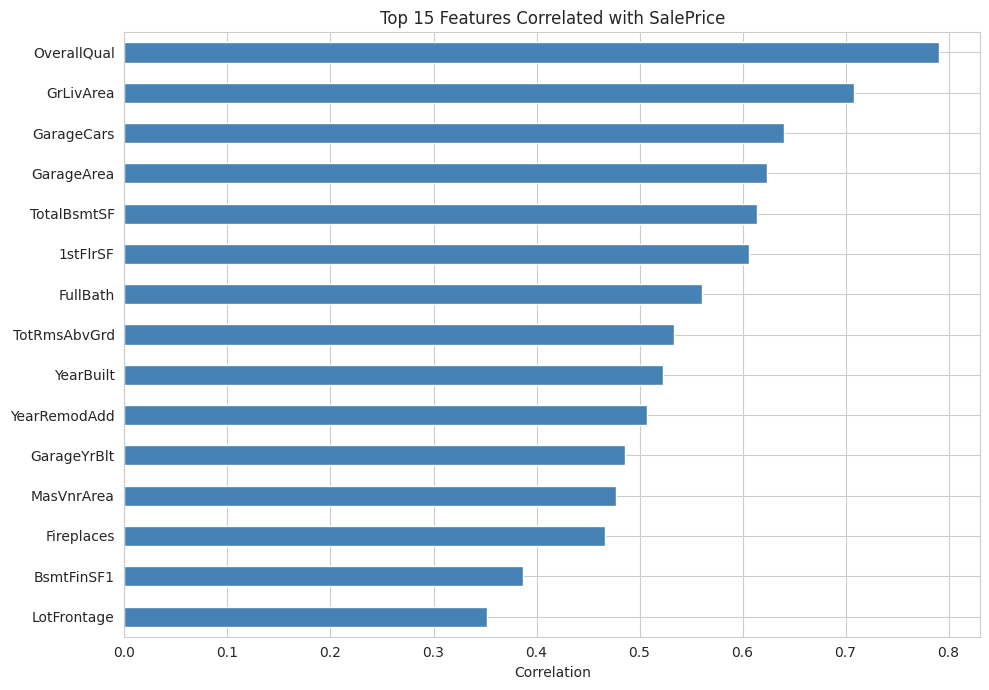

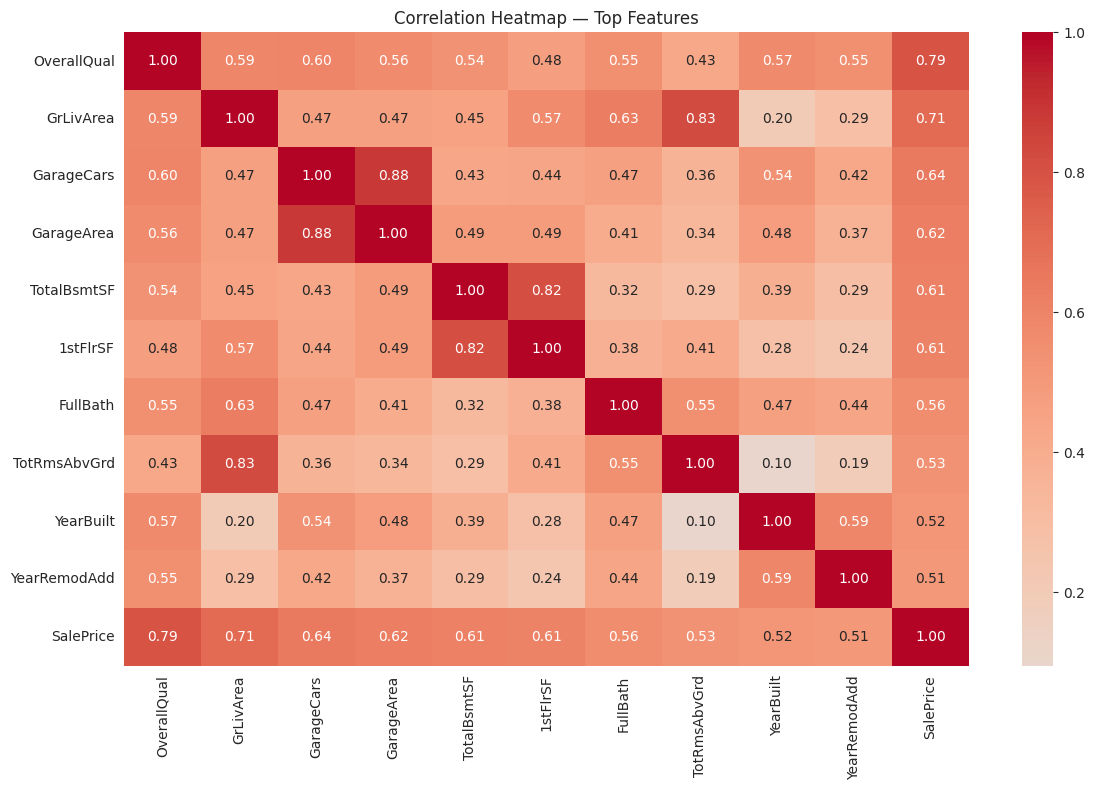

In [6]:
num_df = df.select_dtypes(include=np.number)
correlations = num_df.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

# Bar chart
plt.figure(figsize=(10, 7))
correlations.head(15).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Features Correlated with SalePrice')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

# Heatmap
top_cols = correlations.head(10).index.tolist() + ['SalePrice']
plt.figure(figsize=(12, 8))
sns.heatmap(df[top_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Top Features')
plt.tight_layout()
plt.show()

In [7]:
df_clean = df.copy()

# Drop columns with >40% missing
cols_to_drop = [c for c in df_clean.columns if df_clean[c].isnull().mean() > 0.4]
print(f"Dropping {len(cols_to_drop)} columns: {cols_to_drop}")
df_clean.drop(columns=cols_to_drop, inplace=True)

# Fill categorical nulls with 'None'
cat_cols = df_clean.select_dtypes(include='object').columns
df_clean[cat_cols] = df_clean[cat_cols].fillna('None')

# Fill numerical nulls with median
num_cols = df_clean.select_dtypes(include=np.number).columns
for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Remove outliers
df_clean = df_clean[~((df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 200000))]

print(f"✅ Cleaned! Shape: {df_clean.shape}")
print(f"Missing values left: {df_clean.isnull().sum().sum()}")

Dropping 5 columns: ['Alley', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']
✅ Cleaned! Shape: (1458, 76)
Missing values left: 0


In [8]:
# New features
df_clean['TotalSF']        = df_clean['TotalBsmtSF'] + df_clean['GrLivArea']
df_clean['TotalBathrooms'] = (df_clean['FullBath'] + 0.5 * df_clean['HalfBath'] +
                               df_clean['BsmtFullBath'] + 0.5 * df_clean['BsmtHalfBath'])
df_clean['HouseAge']       = df_clean['YrSold'] - df_clean['YearBuilt']
df_clean['Remodeled']      = (df_clean['YearRemodAdd'] != df_clean['YearBuilt']).astype(int)
df_clean['HasGarage']      = (df_clean['GarageArea'] > 0).astype(int)
df_clean['HasPool']        = (df_clean['PoolArea'] > 0).astype(int)

# Encode categorical columns
le = LabelEncoder()
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

print(f"✅ Features engineered! Final shape: {df_clean.shape}")

✅ Features engineered! Final shape: (1458, 82)


In [9]:
X = df_clean.drop(columns=['Id', 'SalePrice'])
y = np.log1p(df_clean['SalePrice'])  # log transform target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Train: {X_train.shape} | Test: {X_test.shape}")

✅ Train: (1166, 80) | Test: (292, 80)


In [10]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# XGBoost
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("✅ All 3 models trained!")

✅ All 3 models trained!


               Model      RMSE        R²
0            XGBoost  0.119944  0.914658
1  Linear Regression  0.126830  0.904579
2      Random Forest  0.142615  0.879349


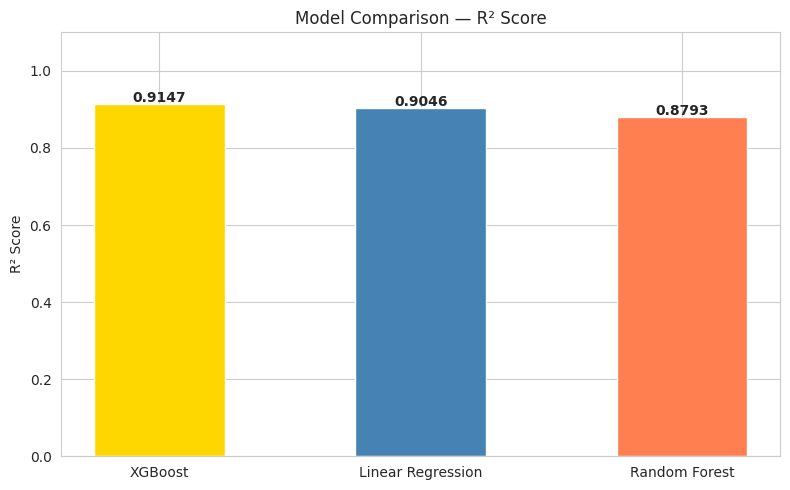

In [11]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE':  [np.sqrt(mean_squared_error(y_test, lr_pred)),
              np.sqrt(mean_squared_error(y_test, rf_pred)),
              np.sqrt(mean_squared_error(y_test, xgb_pred))],
    'R²':    [r2_score(y_test, lr_pred),
              r2_score(y_test, rf_pred),
              r2_score(y_test, xgb_pred)]
}).sort_values('R²', ascending=False).reset_index(drop=True)

print(results)

# Bar chart
plt.figure(figsize=(8, 5))
colors = ['gold', 'steelblue', 'coral']
bars = plt.bar(results['Model'], results['R²'], color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, results['R²']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.title('Model Comparison — R² Score')
plt.ylabel('R² Score')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

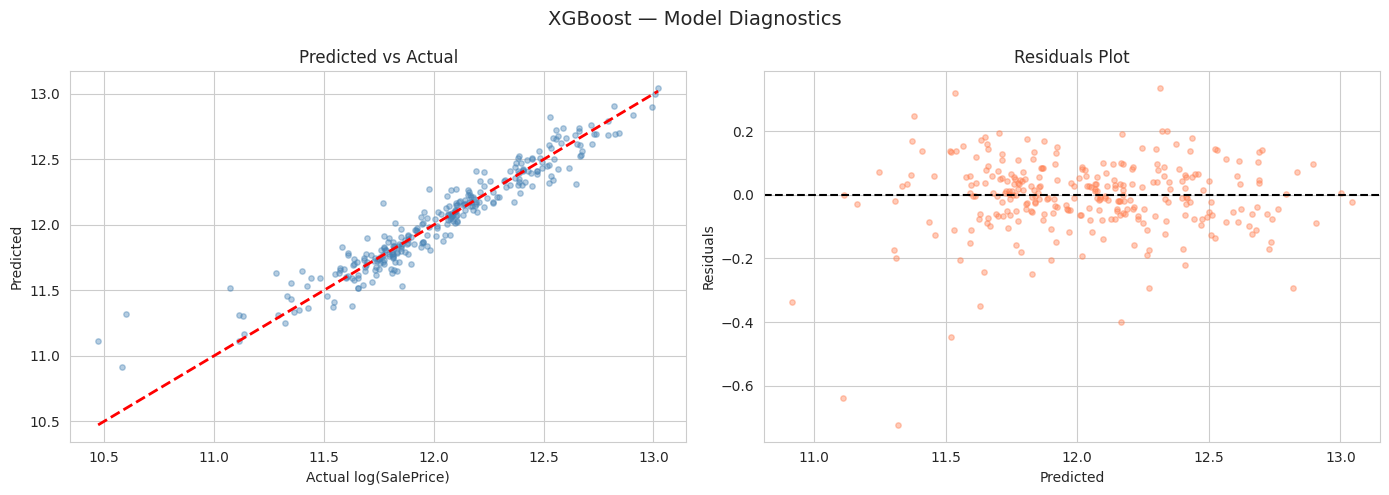

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, xgb_pred, alpha=0.4, color='steelblue', s=15)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual log(SalePrice)')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Predicted vs Actual')

# Residuals
residuals = y_test - xgb_pred
axes[1].scatter(xgb_pred, residuals, alpha=0.4, color='coral', s=15)
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals Plot')

plt.suptitle('XGBoost — Model Diagnostics', fontsize=14)
plt.tight_layout()
plt.show()

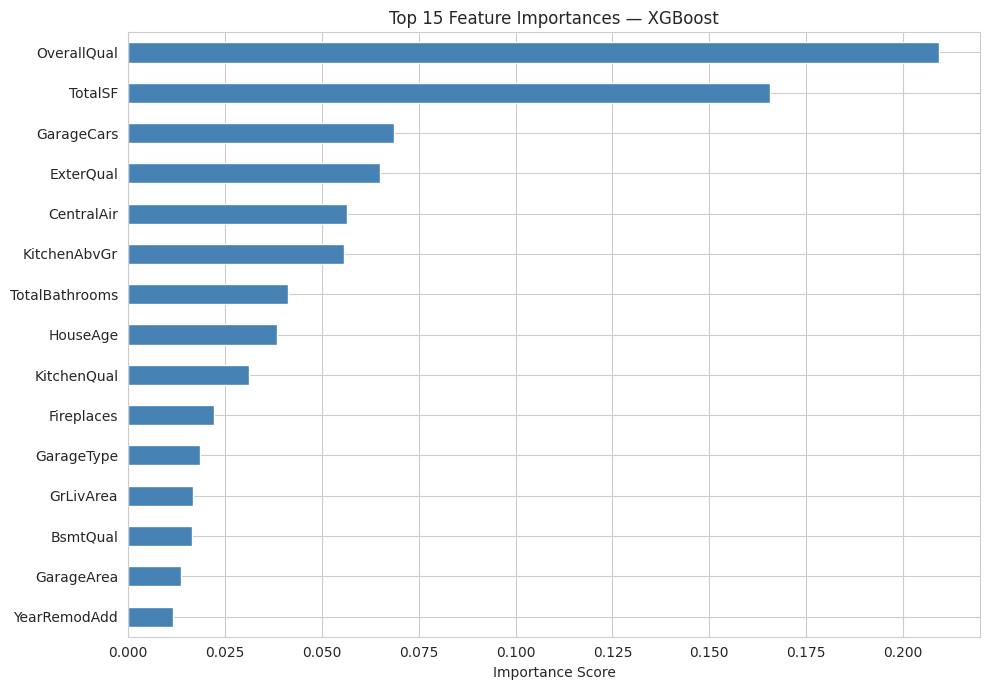

In [13]:
importances = pd.Series(xgb.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=False).head(15).sort_values()

plt.figure(figsize=(10, 7))
top15.plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [14]:
sample = X_test.iloc[[0]]
actual    = np.expm1(y_test.iloc[0])
predicted = np.expm1(xgb.predict(sample)[0])

print("🏠 House Price Prediction")
print(f"   Actual Price:    ${actual:,.0f}")
print(f"   Predicted Price: ${predicted:,.0f}")
print(f"   Difference:      ${abs(actual - predicted):,.0f}")

🏠 House Price Prediction
   Actual Price:    $190,000
   Predicted Price: $212,390
   Difference:      $22,390
